# 05 - TF-IDF Feature Extraction V1

**Objectif** : Construire une première version de features TF-IDF sur la colonne `unified_documents`

**Pipeline** :
1. Chargement du dataset preprocessé (TRAIN uniquement)
2. Preprocessing minimal du texte avec gestion des tokens LaTeX
3. Statistiques descriptives sur le vocabulaire
4. Construction et fit du TfidfVectorizer
5. Analyse du vocabulaire (IDF scores)
6. Sauvegarde des artefacts pour réutilisation

**Note** : Ce notebook ne fait PAS de modélisation, uniquement de l'extraction de features et de l'exploration.


## 1. Imports et Configuration


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from pathlib import Path
from collections import Counter
from typing import List, Tuple
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import save_npz, csr_matrix

warnings.filterwarnings('ignore')

print("Imports loaded successfully")


Imports loaded successfully


In [2]:
# Configuration des tokens LaTeX a traiter
# Modifier cette liste pour ajouter/retirer des commandes LaTeX
LATEX_COMMANDS_TO_TOKEN = {
    r'\\gcd': 'LATEX_GCD',
    r'\\lcm': 'LATEX_LCM',
    r'\\binom': 'LATEX_BINOM',
    r'\\Pr': 'LATEX_PR',
    r'\\sqrt': 'LATEX_SQRT',
    r'\\sum': 'LATEX_SUM',
    r'\\prod': 'LATEX_PROD',
    r'\\log': 'LATEX_LOG',
    r'\\sin': 'LATEX_SIN',
    r'\\cos': 'LATEX_COS',
    r'\\tan': 'LATEX_TAN',
}

print(f"Configuration: {len(LATEX_COMMANDS_TO_TOKEN)} commandes LaTeX a tokeniser")
for cmd, token in LATEX_COMMANDS_TO_TOKEN.items():
    print(f"  {cmd} -> {token}")


Configuration: 11 commandes LaTeX a tokeniser
  \\gcd -> LATEX_GCD
  \\lcm -> LATEX_LCM
  \\binom -> LATEX_BINOM
  \\Pr -> LATEX_PR
  \\sqrt -> LATEX_SQRT
  \\sum -> LATEX_SUM
  \\prod -> LATEX_PROD
  \\log -> LATEX_LOG
  \\sin -> LATEX_SIN
  \\cos -> LATEX_COS
  \\tan -> LATEX_TAN


## 2. Chargement des Donnees


In [3]:
# Charger uniquement le TRAIN set pour eviter tout leakage
data_dir = Path('../data/processed')
train_file = data_dir / 'train_preprocessed.parquet'

print(f"Chargement de: {train_file}")
df = pd.read_parquet(train_file)

print(f"\nDataset charge: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Verifier la presence de la colonne unified_documents
if 'unified_document' not in df.columns:
    raise ValueError("Colonne 'unified_document' non trouvee dans le dataset")

print(f"\nColonne 'unified_document' presente: OK")
print(f"  - Valeurs non-nulles: {df['unified_document'].notna().sum()} / {len(df)}")
print(f"  - Valeurs nulles: {df['unified_document'].isna().sum()}")


Chargement de: ../data/processed/train_preprocessed.parquet

Dataset charge: 3979 lignes, 77 colonnes

Colonne 'unified_document' presente: OK
  - Valeurs non-nulles: 3979 / 3979
  - Valeurs nulles: 0


## 3. Preprocessing du Texte

Preprocessing minimal mais robuste :
- Remplacement des blocs LaTeX math par token `MATHBLOCK`
- Remplacement des commandes LaTeX specifiques par tokens explicites (11 commandes)
- Normalisation des espaces
- Lowercase
- **Tokenisation semantique des nombres** :
  - `NUM_EXP` : notation exponentielle (1e9, 10^9, 2**10)
  - `NUM_FLOAT` : nombres decimaux (3.14, 0.5)
  - `NUM_BIN` : sequences binaires >= 5 bits (10101, 110011)
  - `NUM_INT` : tous les autres entiers (0, 1, 42, 1000, 1000000007)
  - **Preservation** : variables algorithmiques (n, m, k, n1, n2, etc.)


In [4]:
# Variables algorithmiques a preserver
PRESERVE_VARS = {'n', 'm', 'k', 'x', 'y', 'z', 'i', 'j', 'l', 'r'}

def tokenize_numbers(text: str) -> str:
    """
    Remplace les nombres par des tokens semantiques.
    
    Tokens generes:
    - NUM_EXP: notation exponentielle (1e9, 10^9, 2**10)
    - NUM_FLOAT: nombres decimaux (3.14, 0.5)
    - NUM_BIN: sequences binaires >= 5 bits (10101, 110011)
    - NUM_INT: tous les autres entiers (0-10, 42, 1000, 1000000007)
    
    Preserve:
    - Variables algorithmiques: n, m, k, x, y, z, i, j, l, r
    - Variables indexees: n1, n2, m1, k1, etc.
    """
    
    # Etape 1: Notation exponentielle
    # 1e9, 2e5, 1E+9
    text = re.sub(r'\b\d+e[+-]?\d+\b', ' NUM_EXP ', text, flags=re.IGNORECASE)
    # 10^9, 2^10
    text = re.sub(r'\b\d+\^\d+\b', ' NUM_EXP ', text)
    # 10**9, 2**10
    text = re.sub(r'\b\d+\*\*\d+\b', ' NUM_EXP ', text)
    
    # Etape 2: Floats
    text = re.sub(r'\b\d+\.\d+\b', ' NUM_FLOAT ', text)
    
    # Etape 3: Binaires (sequences de 0 et 1 >= 5 bits)
    text = re.sub(r'\b[01]{5,}\b', ' NUM_BIN ', text)
    
    # Etape 4: Entiers (avec preservation des variables)
    def replace_integer(match):
        num_str = match.group(0)
        
        # Preserver variables courantes (n, m, k, etc.)
        if num_str in PRESERVE_VARS:
            return num_str
        
        # Preserver patterns n1, n2, k1, etc.
        if re.match(r'^[nmkxyzijlr]\d+$', num_str):
            return num_str
        
        # Remplacer TOUS les autres entiers
        return ' NUM_INT '
    
    text = re.sub(r'\b\d+\b', replace_integer, text)
    
    # Normaliser les espaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def clean_text(text: str, latex_commands: dict = None) -> str:
    """
    Nettoie un texte avec preprocessing minimal pour TF-IDF.
    
    Etapes:
    1. Remplacement blocs LaTeX math par MATHBLOCK
    2. Remplacement commandes LaTeX specifiques par tokens
    3. Tokenisation semantique des nombres (NUM_EXP, NUM_FLOAT, NUM_BIN, NUM_INT)
    4. Normalisation espaces
    5. Lowercase
    
    Parameters
    ----------
    text : str
        Texte brut a nettoyer
    latex_commands : dict, optional
        Dictionnaire {pattern_regex: token_replacement}
        
    Returns
    -------
    str
        Texte nettoye
    """
    if pd.isna(text) or text == "":
        return ""
    
    text = str(text)
    
    # Etape 1: Remplacer les blocs math LaTeX par MATHBLOCK
    # Display math: $$...$$
    text = re.sub(r'\$\$.*?\$\$', ' MATHBLOCK ', text, flags=re.DOTALL)
    # Inline math: $...$
    text = re.sub(r'\$.*?\$', ' MATHBLOCK ', text)
    # Alternative display: \[...\]
    text = re.sub(r'\\\[.*?\\\]', ' MATHBLOCK ', text, flags=re.DOTALL)
    # Alternative inline: \(...\)
    text = re.sub(r'\\\(.*?\\\)', ' MATHBLOCK ', text)
    
    # Etape 2: Remplacer les commandes LaTeX specifiques par tokens
    if latex_commands is None:
        latex_commands = LATEX_COMMANDS_TO_TOKEN
    
    for pattern, token in latex_commands.items():
        # Pattern insensible a la casse
        text = re.sub(pattern, f' {token} ', text, flags=re.IGNORECASE)
    
    # Etape 3: Normaliser les espaces (multiples espaces, tabs, newlines -> un espace)
    text = re.sub(r'\s+', ' ', text)
    
    # Etape 4: Lowercase
    text = text.lower()
    
    # Etape 5: Tokenisation des nombres (APRES lowercase)
    text = tokenize_numbers(text)
    
    # Etape 6: Trim
    text = text.strip()
    
    return text

print("Fonctions tokenize_numbers et clean_text definies")


Fonctions tokenize_numbers et clean_text definies


In [5]:
# Test de tokenisation des nombres sur quelques exemples
print("="*80)
print("EXEMPLES DE TOKENISATION DES NOMBRES")
print("="*80)
test_examples = [
    "find sum from 1 to 1000",
    "modulo 1000000007",
    "complexity up to 1e9",
    "probability 0.5 or 3.14",
    "binary 101010",
    "calculate 2^10 + 10^9",
    "for i from 0 to 10",
    "n1 and n2 inputs"
]

for example in test_examples:
    result = tokenize_numbers(example)
    print(f"\n  Original:  {example}")
    print(f"  Tokenise:  {result}")

print("\n" + "="*80)

# Appliquer le preprocessing
print("\nApplication du preprocessing sur unified_document...")
df['unified_document_clean'] = df['unified_document'].apply(clean_text)

print(f"\nPreprocessing termine")
print(f"  - Documents traites: {len(df)}")
print(f"  - Documents non-vides apres cleaning: {(df['unified_document_clean'] != '').sum()}")
print(f"  - Documents vides apres cleaning: {(df['unified_document_clean'] == '').sum()}")


EXEMPLES DE TOKENISATION DES NOMBRES

  Original:  find sum from 1 to 1000
  Tokenise:  find sum from NUM_INT to NUM_INT

  Original:  modulo 1000000007
  Tokenise:  modulo NUM_INT

  Original:  complexity up to 1e9
  Tokenise:  complexity up to NUM_EXP

  Original:  probability 0.5 or 3.14
  Tokenise:  probability NUM_FLOAT or NUM_FLOAT

  Original:  binary 101010
  Tokenise:  binary NUM_BIN

  Original:  calculate 2^10 + 10^9
  Tokenise:  calculate NUM_EXP + NUM_EXP

  Original:  for i from 0 to 10
  Tokenise:  for i from NUM_INT to NUM_INT

  Original:  n1 and n2 inputs
  Tokenise:  n1 and n2 inputs


Application du preprocessing sur unified_document...

Preprocessing termine
  - Documents traites: 3979
  - Documents non-vides apres cleaning: 3979
  - Documents vides apres cleaning: 0


## 4. Statistiques sur le Texte

Analyse des longueurs, presence de MATHBLOCK, et exemples avant/apres.


In [6]:
# Distribution des longueurs (caracteres)
df['text_length'] = df['unified_document_clean'].str.len()

print("="*80)
print("STATISTIQUES DES LONGUEURS (caracteres)")
print("="*80)
print(f"\nNombre total de documents: {len(df)}")
print(f"Documents vides ou tres courts (< 50 chars): {(df['text_length'] < 50).sum()} ({(df['text_length'] < 50).sum() / len(df) * 100:.2f}%)")
print(f"\nDistribution des longueurs:")
print(f"  Min:    {df['text_length'].min():>8.0f} chars")
print(f"  P25:    {df['text_length'].quantile(0.25):>8.0f} chars")
print(f"  Median: {df['text_length'].median():>8.0f} chars")
print(f"  P75:    {df['text_length'].quantile(0.75):>8.0f} chars")
print(f"  P95:    {df['text_length'].quantile(0.95):>8.0f} chars")
print(f"  Max:    {df['text_length'].max():>8.0f} chars")
print(f"  Mean:   {df['text_length'].mean():>8.1f} chars")
print(f"  Std:    {df['text_length'].std():>8.1f} chars")


STATISTIQUES DES LONGUEURS (caracteres)

Nombre total de documents: 3979
Documents vides ou tres courts (< 50 chars): 0 (0.00%)

Distribution des longueurs:
  Min:         408 chars
  P25:        1211 chars
  Median:     1591 chars
  P75:        2082 chars
  P95:        3032 chars
  Max:        5807 chars
  Mean:     1713.3 chars
  Std:       705.1 chars


In [7]:
# Statistiques sur MATHBLOCK
df['n_mathblocks'] = df['unified_document_clean'].str.count('mathblock')
docs_with_mathblock = (df['n_mathblocks'] > 0).sum()

print("\n" + "="*80)
print("STATISTIQUES SUR MATHBLOCK")
print("="*80)
print(f"\nDocuments contenant au moins un MATHBLOCK: {docs_with_mathblock} ({docs_with_mathblock / len(df) * 100:.2f}%)")
print(f"\nDistribution du nombre de MATHBLOCK par document:")
print(f"  Min:    {df['n_mathblocks'].min():>6.0f}")
print(f"  Median: {df['n_mathblocks'].median():>6.0f}")
print(f"  Mean:   {df['n_mathblocks'].mean():>6.2f}")
print(f"  Max:    {df['n_mathblocks'].max():>6.0f}")



STATISTIQUES SUR MATHBLOCK

Documents contenant au moins un MATHBLOCK: 2235 (56.17%)

Distribution du nombre de MATHBLOCK par document:
  Min:         0
  Median:     17
  Mean:    18.77
  Max:       120


In [8]:
# Exemples avant/apres
print("\n" + "="*80)
print("EXEMPLES AVANT / APRES PREPROCESSING (5 aleatoires)")
print("="*80)

np.random.seed(42)
sample_indices = np.random.choice(df.index, size=min(5, len(df)), replace=False)

for i, idx in enumerate(sample_indices, 1):
    raw = df.loc[idx, 'unified_document']
    clean = df.loc[idx, 'unified_document_clean']
    
    print(f"\n--- Exemple {i} (index {idx}) ---")
    print(f"\nBRUT (premiers 300 chars):")
    print(raw[:300] if isinstance(raw, str) else str(raw)[:300])
    print(f"\nCLEAN (premiers 300 chars):")
    print(clean[:300] if isinstance(clean, str) else str(clean)[:300])
    print("-" * 80)



EXEMPLES AVANT / APRES PREPROCESSING (5 aleatoires)

--- Exemple 1 (index 408) ---

BRUT (premiers 300 chars):
[DESC] Connect the countless points with lines, till we reach the faraway yonder.There are n points on a coordinate plane, the i-th of which being (i, yi).Determine whether it's possible to draw two parallel and non-overlapping lines, such that every point in the set lies on exactly one of them, and

CLEAN (premiers 300 chars):
[desc] connect the countless points with lines, till we reach the faraway yonder.there are n points on a coordinate plane, the i-th of which being (i, yi).determine whether it's possible to draw two parallel and non-overlapping lines, such that every point in the set lies on exactly one of them, and
--------------------------------------------------------------------------------

--- Exemple 2 (index 3321) ---

BRUT (premiers 300 chars):
[DESC] You are given an array $$$a$$$ of length $$$n$$$. You are asked to process $$$q$$$ queries of the following f

## 5. Statistiques sur le Vocabulaire

Analyse du vocabulaire brut (tokens uniques, frequences, bigrams)


In [9]:
# Tokenisation simple pour statistiques
def simple_tokenize(text: str) -> List[str]:
    """Tokenisation simple basee sur regex mot"""
    if pd.isna(text) or text == "":
        return []
    return re.findall(r'\b\w+\b', str(text).lower())

# Extraire tous les tokens
all_tokens = []
for text in df['unified_document_clean']:
    all_tokens.extend(simple_tokenize(text))

# Compter les frequences
token_counts = Counter(all_tokens)

print("="*80)
print("STATISTIQUES VOCABULAIRE (UNIGRAMS)")
print("="*80)
print(f"\nNombre total de tokens: {len(all_tokens):,}")
print(f"Nombre de tokens uniques: {len(token_counts):,}")

# Compter les tokens numeriques generes
num_int_count = token_counts.get('num_int', 0)
num_float_count = token_counts.get('num_float', 0)
num_exp_count = token_counts.get('num_exp', 0)
num_bin_count = token_counts.get('num_bin', 0)

print(f"\nTokens numeriques generes:")
print(f"  NUM_INT:   {num_int_count:>8,} occurrences")
print(f"  NUM_FLOAT: {num_float_count:>8,} occurrences")
print(f"  NUM_EXP:   {num_exp_count:>8,} occurrences")
print(f"  NUM_BIN:   {num_bin_count:>8,} occurrences")
print(f"  Total:     {num_int_count + num_float_count + num_exp_count + num_bin_count:>8,} occurrences")

print(f"\nTop 30 tokens les plus frequents:")
print("-" * 60)
for token, count in token_counts.most_common(30):
    print(f"  {token:30s} : {count:>8,} occurrences")
    
print("\n" + "="*80)


STATISTIQUES VOCABULAIRE (UNIGRAMS)

Nombre total de tokens: 1,102,543
Nombre de tokens uniques: 17,346

Tokens numeriques generes:
  NUM_INT:     94,971 occurrences
  NUM_FLOAT:      688 occurrences
  NUM_EXP:         13 occurrences
  NUM_BIN:        659 occurrences
  Total:       96,331 occurrences

Top 30 tokens les plus frequents:
------------------------------------------------------------
  num_int                        :   94,971 occurrences
  the                            :   81,262 occurrences
  mathblock                      :   74,679 occurrences
  of                             :   35,903 occurrences
  to                             :   20,439 occurrences
  is                             :   19,160 occurrences
  in                             :   19,065 occurrences
  a                              :   18,393 occurrences
  and                            :   18,006 occurrences
  n                              :   15,104 occurrences
  that                           :   11,01

In [10]:
# Bigrams avec CountVectorizer pour coherence
print("Extraction des bigrams avec CountVectorizer...")
bigram_vectorizer = CountVectorizer(
    analyzer='word',
    lowercase=False,  # Deja en lowercase
    ngram_range=(2, 2),
    min_df=2
)

# Fit sur documents clean
bigram_matrix = bigram_vectorizer.fit_transform(df['unified_document_clean'])
bigram_vocab = bigram_vectorizer.vocabulary_

# Calculer les frequences totales des bigrams
bigram_freqs = bigram_matrix.sum(axis=0).A1
bigram_freq_dict = {bigram: freq for bigram, idx in bigram_vocab.items() 
                    for freq in [bigram_freqs[idx]]}

# Trier par frequence
top_bigrams = sorted(bigram_freq_dict.items(), key=lambda x: x[1], reverse=True)[:30]

print("\n" + "="*80)
print("STATISTIQUES VOCABULAIRE (BIGRAMS)")
print("="*80)
print(f"\nNombre total de bigrams uniques (min_df=2): {len(bigram_vocab):,}")
print(f"\nTop 30 bigrams les plus frequents:")
print("-" * 60)
for bigram, count in top_bigrams:
    print(f"  {bigram:40s} : {count:>8,.0f} occurrences")
    
print("\n" + "="*80)


Extraction des bigrams avec CountVectorizer...

STATISTIQUES VOCABULAIRE (BIGRAMS)

Nombre total de bigrams uniques (min_df=2): 51,756

Top 30 bigrams les plus frequents:
------------------------------------------------------------
  NUM_INT NUM_INT                          :   48,621 occurrences
  mathblock mathblock                      :   43,292 occurrences
  in the                                   :   10,606 occurrences
  of the                                   :   10,556 occurrences
  the first                                :    7,120 occurrences
  n1 NUM_INT                               :    6,487 occurrences
  number of                                :    6,328 occurrences
  NUM_INT n1                               :    5,980 occurrences
  the number                               :    4,785 occurrences
  the second                               :    3,986 occurrences
  NUM_INT n2                               :    3,922 occurrences
  n2 NUM_INT                              

## 6. Construction du TfidfVectorizer

Parametres V1 :
- `analyzer="word"`
- `lowercase=False` (deja fait en preprocessing)
- `ngram_range=(1,2)` (unigrams + bigrams)
- `min_df=2` (minimum 2 documents)
- `max_df=0.95` (maximum 95% des documents)
- `max_features=100000`
- `sublinear_tf=True` (log-scaling des frequences)
- `norm="l2"` (normalisation L2)
- `smooth_idf=True`
- `stop_words=None` (pas de stop-words en V1)


In [14]:
# Initialiser le TfidfVectorizer avec parametres V1
vectorizer = TfidfVectorizer(
    analyzer='word',
    lowercase=False,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True,
    norm='l2',
    smooth_idf=True,
    stop_words=None
)

print("="*80)
print("CONSTRUCTION TF-IDF")
print("="*80)
print("\nParametres du vectorizer:")
print(f"  analyzer:       {vectorizer.analyzer}")
print(f"  lowercase:      {vectorizer.lowercase}")
print(f"  ngram_range:    {vectorizer.ngram_range}")
print(f"  min_df:         {vectorizer.min_df}")
print(f"  max_df:         {vectorizer.max_df}")
print(f"  max_features:   {vectorizer.max_features}")
print(f"  sublinear_tf:   {vectorizer.sublinear_tf}")
print(f"  norm:           {vectorizer.norm}")
print(f"  smooth_idf:     {vectorizer.smooth_idf}")
print(f"  stop_words:     {vectorizer.stop_words}")

print("\nFit + transform du vectorizer sur unified_document_clean...")
X_tfidf = vectorizer.fit_transform(df['unified_document_clean'])

print("\nTF-IDF fit complete!")


CONSTRUCTION TF-IDF

Parametres du vectorizer:
  analyzer:       word
  lowercase:      False
  ngram_range:    (1, 1)
  min_df:         3
  max_df:         0.95
  max_features:   100000
  sublinear_tf:   True
  norm:           l2
  smooth_idf:     True
  stop_words:     None

Fit + transform du vectorizer sur unified_document_clean...

TF-IDF fit complete!


In [15]:
# Statistiques sur la matrice TF-IDF
n_docs, vocab_size = X_tfidf.shape
nnz = X_tfidf.nnz
density = nnz / (n_docs * vocab_size)
memory_mb = X_tfidf.data.nbytes / (1024 * 1024)

print("\n" + "="*80)
print("STATISTIQUES MATRICE TF-IDF")
print("="*80)
print(f"\nShape de la matrice:")
print(f"  Nombre de documents:     {n_docs:>8,}")
print(f"  Taille du vocabulaire:   {vocab_size:>8,}")
print(f"\nSparsite:")
print(f"  Valeurs non-nulles:      {nnz:>12,}")
print(f"  Densite:                 {density:>12.6f} ({density * 100:.4f}%)")
print(f"\nMemoire:")
print(f"  Type:                    {type(X_tfidf).__name__}")
print(f"  Memoire approximative:   {memory_mb:>12.2f} MB")
print(f"\nVocabulaire final:")
print(f"  Taille:                  {len(vectorizer.vocabulary_):>8,} tokens")

print("\n" + "="*80)



STATISTIQUES MATRICE TF-IDF

Shape de la matrice:
  Nombre de documents:        3,979
  Taille du vocabulaire:      5,871

Sparsite:
  Valeurs non-nulles:           362,711
  Densite:                     0.015527 (1.5527%)

Memoire:
  Type:                    csr_matrix
  Memoire approximative:           2.77 MB

Vocabulaire final:
  Taille:                     5,871 tokens



## 7. Analyse du Vocabulaire TF-IDF

Analyse des scores IDF (Inverse Document Frequency)


In [16]:
# Extraire les scores IDF
idf_scores = vectorizer.idf_
feature_names = vectorizer.get_feature_names_out()

# Creer un mapping token -> idf
token_idf = list(zip(feature_names, idf_scores))

# Trier par IDF (plus forte = rare/informatif, plus faible = frequent)
token_idf_sorted = sorted(token_idf, key=lambda x: x[1], reverse=True)

print("="*80)
print("ANALYSE DES SCORES IDF")
print("="*80)

# Top 30 tokens avec plus forte IDF (rare, informatifs)
print("\nTop 30 tokens avec PLUS FORTE IDF (rares, informatifs):")
print("-" * 60)
for token, idf in token_idf_sorted[:30]:
    print(f"  {token:40s} : IDF = {idf:>8.4f}")

# Top 30 tokens avec plus faible IDF (frequents)
print("\n" + "="*80)
print("\nTop 30 tokens avec PLUS FAIBLE IDF (tres frequents):")
print("-" * 60)
for token, idf in token_idf_sorted[-30:]:
    print(f"  {token:40s} : IDF = {idf:>8.4f}")

print("\n" + "="*80)


ANALYSE DES SCORES IDF

Top 30 tokens avec PLUS FORTE IDF (rares, informatifs):
------------------------------------------------------------
  2a                                       : IDF =   7.9027
  2p                                       : IDF =   7.9027
  2t                                       : IDF =   7.9027
  3d                                       : IDF =   7.9027
  3in                                      : IDF =   7.9027
  a1a2                                     : IDF =   7.9027
  abaa                                     : IDF =   7.9027
  abaaba                                   : IDF =   7.9027
  ababab                                   : IDF =   7.9027
  abandoned                                : IDF =   7.9027
  abbreviation                             : IDF =   7.9027
  abd                                      : IDF =   7.9027
  absence                                  : IDF =   7.9027
  acab                                     : IDF =   7.9027
  acceleration     

## 8. Sauvegarde des Artefacts

Sauvegarde du vectorizer et de la matrice TF-IDF pour reutilisation


In [17]:
# Creer le repertoire de sortie
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder le vectorizer
vectorizer_file = output_dir / 'tfidf_vectorizer_v1.pkl'
joblib.dump(vectorizer, vectorizer_file)
print(f"Vectorizer sauvegarde: {vectorizer_file}")

# Sauvegarder la matrice TF-IDF
tfidf_matrix_file = output_dir / 'X_tfidf_train_v1.npz'
save_npz(tfidf_matrix_file, X_tfidf)
print(f"Matrice TF-IDF sauvegardee: {tfidf_matrix_file}")

# Sauvegarder aussi le dataframe avec la colonne clean
df_output_file = output_dir / 'train_with_tfidf_clean.parquet'
df[['src_uid', 'unified_document', 'unified_document_clean', 'text_length', 'n_mathblocks']].to_parquet(df_output_file, index=False)
print(f"DataFrame avec texte clean sauvegarde: {df_output_file}")

print("\nSauvegarde terminee!")


Vectorizer sauvegarde: ../data/processed/tfidf_vectorizer_v1.pkl
Matrice TF-IDF sauvegardee: ../data/processed/X_tfidf_train_v1.npz
DataFrame avec texte clean sauvegarde: ../data/processed/train_with_tfidf_clean.parquet

Sauvegarde terminee!


## 9. Modelisation Simple - Baseline

Objectif : Tester un modele simple (Logistic Regression) avec :
- Features TF-IDF (fit uniquement sur TRAIN)
- Features numeriques, LaTeX et longueur de texte

Pipeline SANS LEAKAGE :
1. Split Train/Val AVANT tout fitting
2. Fit TF-IDF uniquement sur TRAIN
3. Imputation des NaN avec medianes du TRAIN
4. Concatenation des features
5. Modelisation et evaluation

Metriques evaluees :
- Micro-F1 et Macro-F1
- F1, Precision, Recall par label
- Hamming Loss
- Analyse de correlation features/performance


### 📘 Qu'est-ce que la Hamming Loss ?

**Definition** : La Hamming Loss mesure la **fraction de labels incorrectement predits** dans un probleme multi-label.

**Formule** :
```
Hamming Loss = (1 / (n × L)) × Σ XOR(y_true, y_pred)
```

Où :
- `n` = nombre d'échantillons
- `L` = nombre de labels
- `XOR` = différence entre vrai et prédit (0 si correct, 1 si incorrect)

**Interpretation** :
- **0.0** = parfait (aucune erreur)
- **1.0** = catastrophique (toutes les prédictions sont fausses)
- **< 0.1** = généralement bon pour multi-label

**Exemple** :

| Document | Label 1 | Label 2 | Label 3 | Prédiction | Erreurs |
|----------|---------|---------|---------|------------|---------|
| Doc 1    | 1       | 0       | 1       | [1, 0, 0]  | 1 erreur (label 3) |
| Doc 2    | 0       | 1       | 0       | [0, 1, 0]  | 0 erreur |
| Doc 3    | 1       | 1       | 0       | [1, 0, 1]  | 2 erreurs (labels 2 et 3) |

**Hamming Loss** = (1 + 0 + 2) / (3 docs × 3 labels) = **3/9 = 0.333**

**Avantages** :
- ✅ Simple à interpréter
- ✅ Prend en compte tous les labels (pas seulement les positifs)
- ✅ Robuste au déséquilibre des classes

**Différence avec F1** :
- **F1** : se concentre sur les positifs (Precision/Recall)
- **Hamming Loss** : pénalise TOUTES les erreurs (faux positifs ET faux négatifs)

---

### 9.1 Chargement du Dataset Preprocesse


In [27]:
# Charger le dataset complet preprocesse
print("="*80)
print("CHARGEMENT DU DATASET PREPROCESSE")
print("="*80)

df_full = pd.read_parquet(train_file)

print(f"\nDataset: {df_full.shape}")
print(f"  Observations: {len(df_full):,}")
print(f"  Colonnes:     {len(df_full.columns):,}")

# Identifier les colonnes
target_columns = sorted([col for col in df_full.columns if col.startswith('target_')])
latex_binary_features = sorted([col for col in df_full.columns if col.startswith('has_')])

print(f"\n--- Features disponibles ---")
print(f"  Target columns:              {len(target_columns)}")
print(f"  LaTeX binary features (has_): {len(latex_binary_features)}")

# Features numeriques et LaTeX
numeric_features = ['difficulty', 'time_limit_seconds']
latex_stats_features = ['nb_latex_blocks', 'nb_latex_symbols', 'latex_density', 'latex_symbols_density']
text_length_features = [
    'unified_document_char_length', 
    'unified_document_word_count',
    'unified_document_numeric_ratio'
]

print(f"  Numeric features:            {len(numeric_features)}")
print(f"  LaTeX stats features:        {len(latex_stats_features)}")
print(f"  Text length features:        {len(text_length_features)}")

# Verifier la presence des features
all_dense_features = numeric_features + latex_stats_features + latex_binary_features + text_length_features
missing_features = [f for f in all_dense_features if f not in df_full.columns]

if missing_features:
    print(f"\n⚠️  Features manquantes: {missing_features}")
    print("    Ces features seront ignorees")
    all_dense_features = [f for f in all_dense_features if f in df_full.columns]

print(f"\n--- Total features denses: {len(all_dense_features)} ---")

# Afficher distribution des targets
print(f"\n--- Distribution des targets ---")
for col in target_columns[:5]:  # Afficher les 5 premiers
    label_name = col.replace('target_', '')
    n_positive = df_full[col].sum()
    pct_positive = n_positive / len(df_full) * 100
    print(f"  {label_name:25s} : {n_positive:>4} positifs ({pct_positive:>5.2f}%)")
print(f"  ... ({len(target_columns) - 5} autres labels)")

print("\n" + "="*80)


CHARGEMENT DU DATASET PREPROCESSE

Dataset: (3979, 77)
  Observations: 3,979
  Colonnes:     77

--- Features disponibles ---
  Target columns:              8
  LaTeX binary features (has_): 30
  Numeric features:            2
  LaTeX stats features:        4
  Text length features:        3

⚠️  Features manquantes: ['unified_document_char_length', 'unified_document_word_count', 'unified_document_numeric_ratio']
    Ces features seront ignorees

--- Total features denses: 36 ---

--- Distribution des targets ---
  games                     :   87 positifs ( 2.19%)
  geometry                  :  128 positifs ( 3.22%)
  graphs                    :  444 positifs (11.16%)
  math                      : 1127 positifs (28.32%)
  number theory             :  285 positifs ( 7.16%)
  ... (3 autres labels)



### 9.2 Split Train / Validation avec Iterative Stratification

⚠️ **Critique pour eviter le leakage** : Le split doit se faire AVANT de fitter le TF-IDF ou toute autre transformation.

💡 **Iterative Stratification** : Méthode spécialisée pour multi-label qui préserve au mieux la distribution des labels dans train et val.


In [40]:
from scipy.sparse import hstack
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# Extraire les targets
y = df_full[target_columns].values

# Extraire le texte clean et les features denses
texts = df['unified_document_clean'].values
X_dense_full = df_full[all_dense_features].values

print("="*80)
print("SPLIT TRAIN / VALIDATION (ITERATIVE STRATIFICATION)")
print("="*80)

# Utiliser MultilabelStratifiedShuffleSplit pour preserver la distribution des labels
print("\nMethode: MultilabelStratifiedShuffleSplit")
print("  - Preserve au mieux la distribution de chaque label")
print("  - Adapte au multi-label (vs stratify classique)")

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Split avec stratification multi-label
for train_index, val_index in msss.split(X_dense_full, y):
    idx_train = train_index
    idx_val = val_index

# Split des textes
texts_train = texts[idx_train]
texts_val = texts[idx_val]

# Split des features denses
X_dense_train = X_dense_full[idx_train]
X_dense_val = X_dense_full[idx_val]

# Split des targets
y_train = y[idx_train]
y_val = y[idx_val]

print(f"\nTrain set:")
print(f"  Indices:         {len(idx_train):,}")
print(f"  Textes:          {len(texts_train):,}")
print(f"  Features denses: {X_dense_train.shape}")
print(f"  Targets:         {y_train.shape}")
print(f"  Labels/doc (moy):{y_train.sum(axis=1).mean():.2f}")

print(f"\nValidation set:")
print(f"  Indices:         {len(idx_val):,}")
print(f"  Textes:          {len(texts_val):,}")
print(f"  Features denses: {X_dense_val.shape}")
print(f"  Targets:         {y_val.shape}")
print(f"  Labels/doc (moy):{y_val.sum(axis=1).mean():.2f}")

# Verification de la distribution par label
print(f"\n--- Verification de la stratification ---")
print(f"\n{'Label':<25} {'Train %':>10} {'Val %':>10} {'Diff':>10}")
print("-" * 60)

for i, label in enumerate(target_columns):
    label_name = label.replace('target_', '')
    train_pct = (y_train[:, i].sum() / len(y_train)) * 100
    val_pct = (y_val[:, i].sum() / len(y_val)) * 100
    diff = abs(train_pct - val_pct)
    print(f"{label_name:<25} {train_pct:>9.2f}% {val_pct:>9.2f}% {diff:>9.2f}%")

avg_diff = np.mean([abs((y_train[:, i].sum() / len(y_train)) - (y_val[:, i].sum() / len(y_val))) 
                    for i in range(y.shape[1])]) * 100

print(f"\nDifference moyenne de distribution: {avg_diff:.3f}%")
print("  (Plus faible = meilleure stratification)")

print("\n" + "="*80)


SPLIT TRAIN / VALIDATION (ITERATIVE STRATIFICATION)

Methode: MultilabelStratifiedShuffleSplit
  - Preserve au mieux la distribution de chaque label
  - Adapte au multi-label (vs stratify classique)

Train set:
  Indices:         3,183
  Textes:          3,183
  Features denses: (3183, 36)
  Targets:         (3183, 8)
  Labels/doc (moy):0.69

Validation set:
  Indices:         796
  Textes:          796
  Features denses: (796, 36)
  Targets:         (796, 8)
  Labels/doc (moy):0.69

--- Verification de la stratification ---

Label                        Train %      Val %       Diff
------------------------------------------------------------
games                          2.20%      2.14%      0.06%
geometry                       3.20%      3.27%      0.06%
graphs                        11.15%     11.18%      0.03%
math                          28.34%     28.27%      0.07%
number theory                  7.16%      7.16%      0.00%
probabilities                  1.95%      1.88%      

### 9.3 Fit TF-IDF (uniquement sur TRAIN)


In [41]:
print("="*80)
print("FIT TF-IDF SUR TRAIN (SANS LEAKAGE)")
print("="*80)

# Creer un NOUVEAU vectorizer (celui d'avant etait fit sur tout le dataset)
vectorizer_train = TfidfVectorizer(
    analyzer='word',
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True,
    norm='l2',
    smooth_idf=True,
    stop_words=None
)

print("\nParametres TF-IDF:")
print(f"  ngram_range:  {vectorizer_train.ngram_range}")
print(f"  min_df:       {vectorizer_train.min_df}")
print(f"  max_df:       {vectorizer_train.max_df}")
print(f"  max_features: {vectorizer_train.max_features}")

# FIT uniquement sur TRAIN
print(f"\nFit sur TRAIN: {len(texts_train):,} documents...")
import time
start_time = time.time()
X_tfidf_train = vectorizer_train.fit_transform(texts_train)
fit_time = time.time() - start_time

print(f"  Temps: {fit_time:.2f}s")
print(f"  Vocabulaire: {len(vectorizer_train.vocabulary_):,} tokens")
print(f"  Shape: {X_tfidf_train.shape}")

# TRANSFORM sur VAL (sans refit)
print(f"\nTransform sur VAL: {len(texts_val):,} documents...")
X_tfidf_val = vectorizer_train.transform(texts_val)
print(f"  Shape: {X_tfidf_val.shape}")

# Verification: meme vocabulaire
assert X_tfidf_train.shape[1] == X_tfidf_val.shape[1], "Vocabulaire different!"
print(f"\n✅ Vocabulaire identique: {X_tfidf_train.shape[1]:,} features")

print("\n" + "="*80)


FIT TF-IDF SUR TRAIN (SANS LEAKAGE)

Parametres TF-IDF:
  ngram_range:  (1, 2)
  min_df:       2
  max_df:       0.95
  max_features: 100000

Fit sur TRAIN: 3,183 documents...
  Temps: 1.50s
  Vocabulaire: 49,956 tokens
  Shape: (3183, 49956)

Transform sur VAL: 796 documents...
  Shape: (796, 49956)

✅ Vocabulaire identique: 49,956 features



### 9.4 Imputation et Concatenation des Features


In [42]:
print("="*80)
print("IMPUTATION DES NaN (UNIQUEMENT SUR TRAIN)")
print("="*80)

# Convertir en DataFrame pour faciliter l'imputation
X_dense_train_df = pd.DataFrame(X_dense_train, columns=all_dense_features)
X_dense_val_df = pd.DataFrame(X_dense_val, columns=all_dense_features)

# Identifier les colonnes avec NaN dans TRAIN
cols_with_nan = X_dense_train_df.columns[X_dense_train_df.isna().any()].tolist()

print(f"\nColonnes avec NaN dans TRAIN: {len(cols_with_nan)}")
if cols_with_nan:
    for col in cols_with_nan:
        n_nan_train = X_dense_train_df[col].isna().sum()
        n_nan_val = X_dense_val_df[col].isna().sum()
        print(f"  {col:35s} : {n_nan_train:>4} NaN train, {n_nan_val:>4} NaN val")
    
    # Calculer medianes sur TRAIN uniquement
    print(f"\nCalcul des medianes sur TRAIN...")
    fill_values = {}
    for col in cols_with_nan:
        if X_dense_train_df[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            fill_values[col] = X_dense_train_df[col].median()
        else:
            # Pour colonnes non-numeriques, utiliser mode
            fill_values[col] = X_dense_train_df[col].mode()[0] if len(X_dense_train_df[col].mode()) > 0 else 0
    
    print(f"  Valeurs d'imputation calculees: {len(fill_values)}")
    for col, val in fill_values.items():
        print(f"    {col:35s} : {val:.2f}")
    
    # Appliquer l'imputation sur TRAIN et VAL
    print(f"\nApplication de l'imputation...")
    X_dense_train_df = X_dense_train_df.fillna(fill_values)
    X_dense_val_df = X_dense_val_df.fillna(fill_values)
    
    # Verifier
    n_nan_train_after = X_dense_train_df.isna().sum().sum()
    n_nan_val_after = X_dense_val_df.isna().sum().sum()
    print(f"  NaN restants train: {n_nan_train_after}")
    print(f"  NaN restants val:   {n_nan_val_after}")
else:
    print("  Aucune colonne avec NaN")

# Convertir en numpy
X_dense_train_imputed = X_dense_train_df.values
X_dense_val_imputed = X_dense_val_df.values

print("\n" + "="*80)
print("CONCATENATION DES FEATURES")
print("="*80)

# Concatener TF-IDF (sparse) + features denses
print(f"\nTRAIN:")
print(f"  TF-IDF:  {X_tfidf_train.shape} (sparse)")
print(f"  Dense:   {X_dense_train_imputed.shape}")

X_train_full = hstack([X_tfidf_train, X_dense_train_imputed])
print(f"  TOTAL:   {X_train_full.shape}")

print(f"\nVAL:")
print(f"  TF-IDF:  {X_tfidf_val.shape} (sparse)")
print(f"  Dense:   {X_dense_val_imputed.shape}")

X_val_full = hstack([X_tfidf_val, X_dense_val_imputed])
print(f"  TOTAL:   {X_val_full.shape}")

print(f"\n✅ Features concatenees")
print(f"  Type: {type(X_train_full)}")
print(f"  Densite: {X_train_full.nnz / (X_train_full.shape[0] * X_train_full.shape[1]):.6f}")

print("\n" + "="*80)

# Stocker les noms des features denses pour analyse ulterieure
dense_feature_names = all_dense_features


IMPUTATION DES NaN (UNIQUEMENT SUR TRAIN)

Colonnes avec NaN dans TRAIN: 0
  Aucune colonne avec NaN

CONCATENATION DES FEATURES

TRAIN:
  TF-IDF:  (3183, 49956) (sparse)
  Dense:   (3183, 36)
  TOTAL:   (3183, 49992)

VAL:
  TF-IDF:  (796, 49956) (sparse)
  Dense:   (796, 36)
  TOTAL:   (796, 49992)

✅ Features concatenees
  Type: <class 'scipy.sparse._coo.coo_matrix'>
  Densite: 0.004908



### 9.5 Entrainement du Modele


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

print("="*80)
print("ENTRAINEMENT DU MODELE")
print("="*80)

# Modele: LogisticRegression avec OneVsRestClassifier
model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    n_jobs=-1
)

print(f"\nModele: OneVsRestClassifier(LogisticRegression)")
print(f"  Parametres:")
print(f"    - C=1.0")
print(f"    - max_iter=1000")
print(f"    - solver='lbfgs'")
print(f"    - class_weight='balanced'")

print(f"\nEntrainement sur:")
print(f"  Samples: {X_train_full.shape[0]:,}")
print(f"  Features: {X_train_full.shape[1]:,}")
print(f"    - TF-IDF: {X_tfidf_train.shape[1]:,}")
print(f"    - Dense:  {len(dense_feature_names):,}")

start_time = time.time()
model.fit(X_train_full, y_train)
train_time = time.time() - start_time

print(f"\nEntrainement termine en {train_time:.2f}s ({train_time/60:.2f} min)")
print("\n" + "="*80)


ENTRAINEMENT DU MODELE

Modele: OneVsRestClassifier(LogisticRegression)
  Parametres:
    - C=1.0
    - max_iter=1000
    - solver='lbfgs'
    - class_weight='balanced'

Entrainement sur:
  Samples: 3,183
  Features: 49,992
    - TF-IDF: 49,956
    - Dense:  36

Entrainement termine en 46.86s (0.78 min)



### 9.6 Predictions et Metriques


In [44]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    hamming_loss, classification_report
)

# Predictions
print("Generation des predictions...")
y_train_pred = model.predict(X_train_full)
y_val_pred = model.predict(X_val_full)

print(f"  Train: {y_train_pred.shape}")
print(f"  Val:   {y_val_pred.shape}")

# Calculer les metriques globales
print("\n" + "="*80)
print("METRIQUES GLOBALES")
print("="*80)

# Micro-F1
micro_f1_train = f1_score(y_train, y_train_pred, average='micro')
micro_f1_val = f1_score(y_val, y_val_pred, average='micro')

# Macro-F1
macro_f1_train = f1_score(y_train, y_train_pred, average='macro')
macro_f1_val = f1_score(y_val, y_val_pred, average='macro')

# Hamming Loss
hamming_train = hamming_loss(y_train, y_train_pred)
hamming_val = hamming_loss(y_val, y_val_pred)

# Precision et Recall globaux
micro_prec_train = precision_score(y_train, y_train_pred, average='micro')
micro_prec_val = precision_score(y_val, y_val_pred, average='micro')
micro_rec_train = recall_score(y_train, y_train_pred, average='micro')
micro_rec_val = recall_score(y_val, y_val_pred, average='micro')

print("\n--- Micro-averaged (global) ---")
print(f"TRAIN:")
print(f"  Micro-F1:        {micro_f1_train:.4f}")
print(f"  Micro-Precision: {micro_prec_train:.4f}")
print(f"  Micro-Recall:    {micro_rec_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Micro-F1:        {micro_f1_val:.4f}")
print(f"  Micro-Precision: {micro_prec_val:.4f}")
print(f"  Micro-Recall:    {micro_rec_val:.4f}")

print("\n--- Macro-averaged (par label) ---")
print(f"TRAIN:")
print(f"  Macro-F1:        {macro_f1_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Macro-F1:        {macro_f1_val:.4f}")

print("\n--- Hamming Loss ---")
print(f"TRAIN:")
print(f"  Hamming Loss:    {hamming_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Hamming Loss:    {hamming_val:.4f}")

print("\n" + "="*80)


Generation des predictions...
  Train: (3183, 8)
  Val:   (796, 8)

METRIQUES GLOBALES

--- Micro-averaged (global) ---
TRAIN:
  Micro-F1:        0.7624
  Micro-Precision: 0.6472
  Micro-Recall:    0.9276

VALIDATION:
  Micro-F1:        0.5489
  Micro-Precision: 0.4833
  Micro-Recall:    0.6350

--- Macro-averaged (par label) ---
TRAIN:
  Macro-F1:        0.7759

VALIDATION:
  Macro-F1:        0.5344

--- Hamming Loss ---
TRAIN:
  Hamming Loss:    0.0499

VALIDATION:
  Hamming Loss:    0.0898



In [45]:
# Calculer les metriques par label
print("\n" + "="*80)
print("METRIQUES PAR LABEL (VALIDATION)")
print("="*80)

# Calculer F1, Precision, Recall pour chaque label
f1_per_label = f1_score(y_val, y_val_pred, average=None)
precision_per_label = precision_score(y_val, y_val_pred, average=None, zero_division=0)
recall_per_label = recall_score(y_val, y_val_pred, average=None, zero_division=0)

# Creer un DataFrame pour affichage propre
metrics_per_label = pd.DataFrame({
    'Label': [col.replace('target_', '') for col in target_columns],
    'F1': f1_per_label,
    'Precision': precision_per_label,
    'Recall': recall_per_label,
    'Support': y_val.sum(axis=0)
})

# Trier par F1 decroissant
metrics_per_label = metrics_per_label.sort_values('F1', ascending=False).reset_index(drop=True)

print("\n" + "-"*80)
print(f"{'Label':<25} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Support':>8}")
print("-"*80)

for idx, row in metrics_per_label.iterrows():
    print(f"{row['Label']:<25} {row['F1']:>8.4f} {row['Precision']:>10.4f} {row['Recall']:>8.4f} {row['Support']:>8.0f}")

print("-"*80)
print(f"{'MACRO-AVERAGE':<25} {metrics_per_label['F1'].mean():>8.4f} {metrics_per_label['Precision'].mean():>10.4f} {metrics_per_label['Recall'].mean():>8.4f} {metrics_per_label['Support'].sum():>8.0f}")
print("="*80)



METRIQUES PAR LABEL (VALIDATION)

--------------------------------------------------------------------------------
Label                           F1  Precision   Recall  Support
--------------------------------------------------------------------------------
games                       0.6829     0.5833   0.8235       17
strings                     0.6788     0.5773   0.8235       68
trees                       0.5812     0.5152   0.6667       51
graphs                      0.5687     0.4918   0.6742       89
math                        0.5514     0.5134   0.5956      225
geometry                    0.5000     0.4412   0.5769       26
number theory               0.3862     0.3182   0.4912       57
probabilities               0.3256     0.2500   0.4667       15
--------------------------------------------------------------------------------
MACRO-AVERAGE               0.5344     0.4613   0.6398      548


### 9.7 Optimisation des Seuils de Decision par Label

Actuellement, le modele utilise un seuil de 0.5 pour tous les labels. Etant donne que Recall >> Precision, nous allons optimiser le seuil par label pour maximiser le F1 score.


In [46]:
print("="*80)
print("OPTIMISATION DES SEUILS PAR LABEL")
print("="*80)

# Obtenir les probabilites au lieu des predictions binaires
print("\nCalcul des probabilites...")
y_train_proba = model.predict_proba(X_train_full)
y_val_proba = model.predict_proba(X_val_full)

# Pour OneVsRestClassifier, predict_proba retourne une liste de arrays
# Convertir en matrice (n_samples, n_labels)
if isinstance(y_train_proba, list):
    y_train_proba = np.column_stack([proba[:, 1] for proba in y_train_proba])
    y_val_proba = np.column_stack([proba[:, 1] for proba in y_val_proba])

print(f"  Train proba: {y_train_proba.shape}")
print(f"  Val proba:   {y_val_proba.shape}")

# Fonction pour trouver le seuil optimal par label
def find_optimal_threshold(y_true, y_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Trouve le seuil qui maximise le F1 score pour un label donne.
    
    Parameters
    ----------
    y_true : array
        Vraies valeurs (0 ou 1)
    y_proba : array
        Probabilites predites
    thresholds : array
        Seuils a tester
        
    Returns
    -------
    best_threshold : float
        Seuil optimal
    best_f1 : float
        F1 score au seuil optimal
    """
    best_f1 = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred_threshold = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred_threshold, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

# Optimiser les seuils sur le TRAIN set
print(f"\nOptimisation des seuils sur TRAIN...")
print(f"  Seuils testes: {np.arange(0.1, 0.9, 0.05)}")

optimal_thresholds = []
for i, label in enumerate(target_columns):
    label_name = label.replace('target_', '')
    threshold, f1_train = find_optimal_threshold(y_train[:, i], y_train_proba[:, i])
    optimal_thresholds.append(threshold)
    print(f"  {label_name:25s} : seuil={threshold:.2f}, F1_train={f1_train:.4f}")

optimal_thresholds = np.array(optimal_thresholds)

# Appliquer les seuils optimaux sur TRAIN et VAL
print(f"\nApplication des seuils optimaux...")
y_train_pred_opt = (y_train_proba >= optimal_thresholds).astype(int)
y_val_pred_opt = (y_val_proba >= optimal_thresholds).astype(int)

print(f"  Train pred optimized: {y_train_pred_opt.shape}")
print(f"  Val pred optimized:   {y_val_pred_opt.shape}")

print("\n" + "="*80)


OPTIMISATION DES SEUILS PAR LABEL

Calcul des probabilites...
  Train proba: (3183, 8)
  Val proba:   (796, 8)

Optimisation des seuils sur TRAIN...
  Seuils testes: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85]
  games                     : seuil=0.80, F1_train=0.9790
  geometry                  : seuil=0.75, F1_train=0.9619
  graphs                    : seuil=0.60, F1_train=0.8142
  math                      : seuil=0.50, F1_train=0.7398
  number theory             : seuil=0.60, F1_train=0.7938
  probabilities             : seuil=0.80, F1_train=0.9538
  strings                   : seuil=0.60, F1_train=0.8274
  trees                     : seuil=0.70, F1_train=0.8651

Application des seuils optimaux...
  Train pred optimized: (3183, 8)
  Val pred optimized:   (796, 8)



In [47]:
# Comparaison des metriques AVANT vs APRES optimisation
print("="*80)
print("COMPARAISON AVANT / APRES OPTIMISATION DES SEUILS")
print("="*80)

# Metriques globales APRES optimisation
micro_f1_train_opt = f1_score(y_train, y_train_pred_opt, average='micro')
micro_f1_val_opt = f1_score(y_val, y_val_pred_opt, average='micro')
macro_f1_train_opt = f1_score(y_train, y_train_pred_opt, average='macro')
macro_f1_val_opt = f1_score(y_val, y_val_pred_opt, average='macro')
hamming_train_opt = hamming_loss(y_train, y_train_pred_opt)
hamming_val_opt = hamming_loss(y_val, y_val_pred_opt)
micro_prec_train_opt = precision_score(y_train, y_train_pred_opt, average='micro')
micro_prec_val_opt = precision_score(y_val, y_val_pred_opt, average='micro')
micro_rec_train_opt = recall_score(y_train, y_train_pred_opt, average='micro')
micro_rec_val_opt = recall_score(y_val, y_val_pred_opt, average='micro')

# Tableau comparatif VALIDATION
print("\n--- VALIDATION SET ---")
print(f"\n{'Metrique':<20} {'Seuil 0.5':>12} {'Seuil Optimal':>14} {'Gain':>10}")
print("-" * 60)
print(f"{'Micro-F1':<20} {micro_f1_val:>12.4f} {micro_f1_val_opt:>14.4f} {(micro_f1_val_opt - micro_f1_val):>9.4f}")
print(f"{'Macro-F1':<20} {macro_f1_val:>12.4f} {macro_f1_val_opt:>14.4f} {(macro_f1_val_opt - macro_f1_val):>9.4f}")
print(f"{'Micro-Precision':<20} {micro_prec_val:>12.4f} {micro_prec_val_opt:>14.4f} {(micro_prec_val_opt - micro_prec_val):>9.4f}")
print(f"{'Micro-Recall':<20} {micro_rec_val:>12.4f} {micro_rec_val_opt:>14.4f} {(micro_rec_val_opt - micro_rec_val):>9.4f}")
print(f"{'Hamming Loss':<20} {hamming_val:>12.4f} {hamming_val_opt:>14.4f} {(hamming_val_opt - hamming_val):>9.4f}")

# Pourcentage de gain
gain_micro_f1 = ((micro_f1_val_opt - micro_f1_val) / micro_f1_val) * 100
gain_macro_f1 = ((macro_f1_val_opt - macro_f1_val) / macro_f1_val) * 100

print(f"\n💡 Gain relatif:")
print(f"   Micro-F1: {gain_micro_f1:+.2f}%")
print(f"   Macro-F1: {gain_macro_f1:+.2f}%")

print("\n" + "="*80)


COMPARAISON AVANT / APRES OPTIMISATION DES SEUILS

--- VALIDATION SET ---

Metrique                Seuil 0.5  Seuil Optimal       Gain
------------------------------------------------------------
Micro-F1                   0.5489         0.5495    0.0006
Macro-F1                   0.5344         0.5093   -0.0250
Micro-Precision            0.4833         0.5375    0.0542
Micro-Recall               0.6350         0.5620   -0.0730
Hamming Loss               0.0898         0.0793   -0.0105

💡 Gain relatif:
   Micro-F1: +0.11%
   Macro-F1: -4.69%



In [48]:
# Comparaison par label
print("="*80)
print("COMPARAISON PAR LABEL (VALIDATION)")
print("="*80)

# Metriques par label APRES optimisation
f1_per_label_opt = f1_score(y_val, y_val_pred_opt, average=None)
precision_per_label_opt = precision_score(y_val, y_val_pred_opt, average=None, zero_division=0)
recall_per_label_opt = recall_score(y_val, y_val_pred_opt, average=None, zero_division=0)

# Creer DataFrame comparatif
comparison_df = pd.DataFrame({
    'Label': [col.replace('target_', '') for col in target_columns],
    'Seuil': optimal_thresholds,
    'F1_avant': f1_per_label,
    'F1_apres': f1_per_label_opt,
    'Gain_F1': f1_per_label_opt - f1_per_label,
    'Prec_avant': precision_per_label,
    'Prec_apres': precision_per_label_opt,
    'Rec_avant': recall_per_label,
    'Rec_apres': recall_per_label_opt,
    'Support': y_val.sum(axis=0)
})

# Trier par gain F1 decroissant
comparison_df = comparison_df.sort_values('Gain_F1', ascending=False).reset_index(drop=True)

print("\n" + "-"*100)
print(f"{'Label':<20} {'Seuil':>7} {'F1 Avant':>10} {'F1 Apres':>10} {'Gain F1':>10} {'Prec->':>8} {'Rec->':>8}")
print("-"*100)

for idx, row in comparison_df.iterrows():
    print(f"{row['Label']:<20} {row['Seuil']:>7.2f} {row['F1_avant']:>10.4f} {row['F1_apres']:>10.4f} {row['Gain_F1']:>10.4f} {row['Prec_apres']:>8.4f} {row['Rec_apres']:>8.4f}")

print("-"*100)

# Statistiques sur les gains
print(f"\n📊 Statistiques des gains F1:")
print(f"   Moyenne:  {comparison_df['Gain_F1'].mean():>+8.4f}")
print(f"   Mediane:  {comparison_df['Gain_F1'].median():>+8.4f}")
print(f"   Min:      {comparison_df['Gain_F1'].min():>+8.4f} ({comparison_df.loc[comparison_df['Gain_F1'].idxmin(), 'Label']})")
print(f"   Max:      {comparison_df['Gain_F1'].max():>+8.4f} ({comparison_df.loc[comparison_df['Gain_F1'].idxmax(), 'Label']})")
print(f"   Labels ameliores: {(comparison_df['Gain_F1'] > 0).sum()} / {len(comparison_df)}")

print("\n" + "="*80)


COMPARAISON PAR LABEL (VALIDATION)

----------------------------------------------------------------------------------------------------
Label                  Seuil   F1 Avant   F1 Apres    Gain F1   Prec->    Rec->
----------------------------------------------------------------------------------------------------
games                   0.80     0.6829     0.7407     0.0578   1.0000   0.5882
strings                 0.60     0.6788     0.7044     0.0256   0.6154   0.8235
graphs                  0.60     0.5687     0.5730     0.0043   0.5521   0.5955
math                    0.50     0.5514     0.5514     0.0000   0.5134   0.5956
trees                   0.70     0.5812     0.5745    -0.0067   0.6279   0.5294
number theory           0.60     0.3862     0.3273    -0.0589   0.3396   0.3158
probabilities           0.80     0.3256     0.2222    -0.1034   0.6667   0.1333
geometry                0.75     0.5000     0.3810    -0.1190   0.5000   0.3077
------------------------------------------

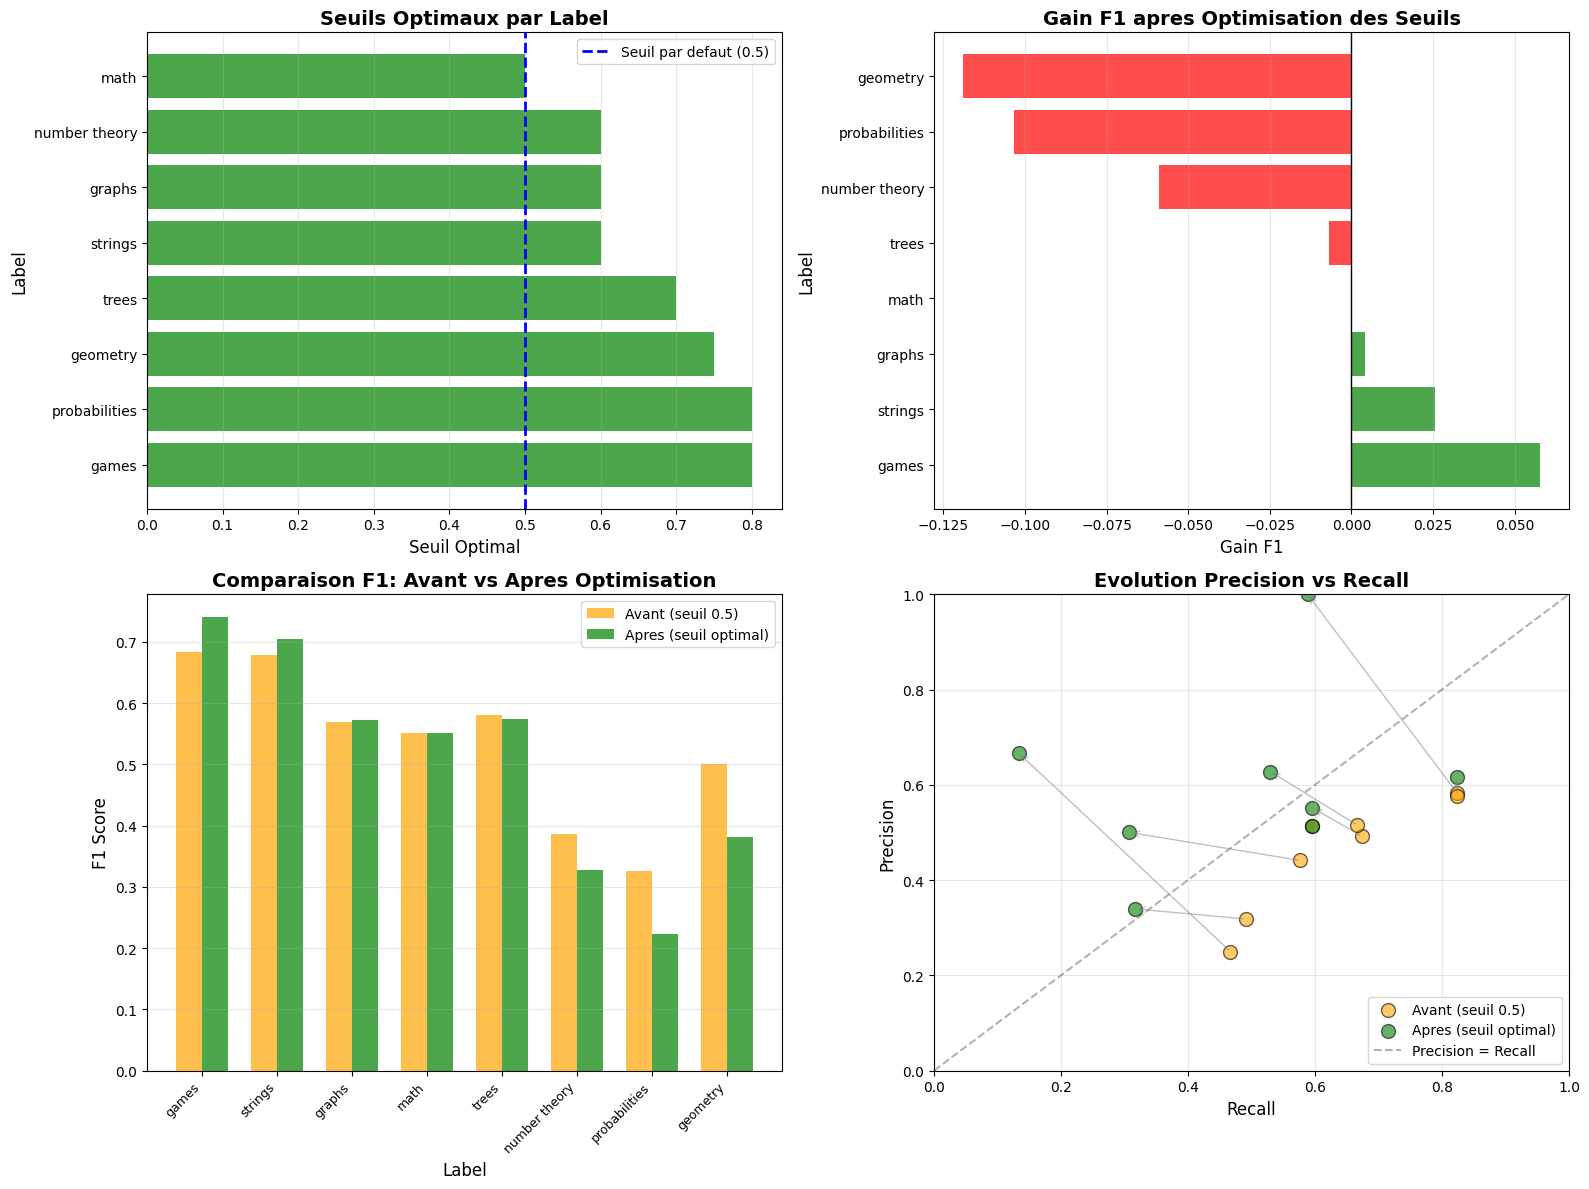

Visualisations generees


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation de l'impact de l'optimisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Seuils optimaux par label
ax1 = axes[0, 0]
comparison_sorted = comparison_df.sort_values('Seuil', ascending=False)
colors_thres = ['red' if t < 0.5 else 'green' for t in comparison_sorted['Seuil']]
ax1.barh(comparison_sorted['Label'], comparison_sorted['Seuil'], color=colors_thres, alpha=0.7)
ax1.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Seuil par defaut (0.5)')
ax1.set_xlabel('Seuil Optimal', fontsize=12)
ax1.set_ylabel('Label', fontsize=12)
ax1.set_title('Seuils Optimaux par Label', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Gain F1 par label
ax2 = axes[0, 1]
colors_gain = ['green' if g > 0 else 'red' for g in comparison_df['Gain_F1']]
ax2.barh(comparison_df['Label'], comparison_df['Gain_F1'], color=colors_gain, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Gain F1', fontsize=12)
ax2.set_ylabel('Label', fontsize=12)
ax2.set_title('Gain F1 apres Optimisation des Seuils', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: F1 avant vs apres
ax3 = axes[1, 0]
x = np.arange(len(comparison_df))
width = 0.35
ax3.bar(x - width/2, comparison_df['F1_avant'], width, label='Avant (seuil 0.5)', alpha=0.7, color='orange')
ax3.bar(x + width/2, comparison_df['F1_apres'], width, label='Apres (seuil optimal)', alpha=0.7, color='green')
ax3.set_xlabel('Label', fontsize=12)
ax3.set_ylabel('F1 Score', fontsize=12)
ax3.set_title('Comparaison F1: Avant vs Apres Optimisation', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([l[:15] for l in comparison_df['Label']], rotation=45, ha='right', fontsize=9)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Precision vs Recall (avant et apres)
ax4 = axes[1, 1]
ax4.scatter(comparison_df['Rec_avant'], comparison_df['Prec_avant'], 
           s=100, alpha=0.6, color='orange', edgecolors='black', linewidth=1,
           label='Avant (seuil 0.5)')
ax4.scatter(comparison_df['Rec_apres'], comparison_df['Prec_apres'],
           s=100, alpha=0.6, color='green', edgecolors='black', linewidth=1,
           label='Apres (seuil optimal)')

# Fleches montrant l'evolution
for i, row in comparison_df.iterrows():
    ax4.annotate('', 
                xy=(row['Rec_apres'], row['Prec_apres']),
                xytext=(row['Rec_avant'], row['Prec_avant']),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))

ax4.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Precision = Recall')
ax4.set_xlabel('Recall', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Evolution Precision vs Recall', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Visualisations generees")


### 9.8 Analyse de Correlation Features vs Performance

Analyse de la correlation entre les features denses et les performances par label pour identifier les features les plus predictives.


In [50]:
print("="*80)
print("ANALYSE DE CORRELATION FEATURES DENSES")
print("="*80)

# Extraire seulement les features denses (pas le TF-IDF)
n_tfidf_features = X_tfidf_train.shape[1]
X_dense_train_corr = X_dense_train_imputed
X_dense_val_corr = X_dense_val_imputed

print(f"\nFeatures denses analysees: {len(dense_feature_names)}")

# Calculer la correlation entre chaque feature dense et chaque target
correlations = []
for i, feature_name in enumerate(dense_feature_names):
    feature_values_train = X_dense_train_corr[:, i]
    feature_corr_per_label = []
    
    for j, target_name in enumerate(target_columns):
        # Correlation de Pearson entre feature et target
        corr = np.corrcoef(feature_values_train, y_train[:, j])[0, 1]
        feature_corr_per_label.append(corr)
    
    correlations.append(feature_corr_per_label)

# Creer DataFrame de correlations
corr_df = pd.DataFrame(
    correlations,
    index=dense_feature_names,
    columns=[col.replace('target_', '') for col in target_columns]
)

# Afficher les features les plus correlees pour chaque label
print("\n--- Top 5 features correlees par label (abs) ---")
for label in corr_df.columns[:5]:  # Afficher 5 premiers labels
    print(f"\n{label}:")
    top_features = corr_df[label].abs().nlargest(5)
    for feat, corr_val in top_features.items():
        print(f"  {feat:35s} : {corr_df.loc[feat, label]:>7.4f}")

# Afficher les features globalement les plus correlees
print("\n--- Features les plus correlees globalement (moyenne abs) ---")
mean_abs_corr = corr_df.abs().mean(axis=1).sort_values(ascending=False)
print(f"\nTop 10 features:")
for feat, mean_corr in mean_abs_corr.head(10).items():
    print(f"  {feat:35s} : {mean_corr:>7.4f}")

print("\n" + "="*80)


ANALYSE DE CORRELATION FEATURES DENSES

Features denses analysees: 36

--- Top 5 features correlees par label (abs) ---

games:
  has_text                            :  0.0519
  has_times                           :  0.0398
  latex_density                       : -0.0375
  difficulty                          :  0.0336
  has_dots                            : -0.0286

geometry:
  difficulty                          :  0.0758
  nb_latex_blocks                     : -0.0508
  has_dots                            : -0.0407
  latex_density                       : -0.0382
  has_le                              : -0.0352

graphs:
  difficulty                          :  0.1967
  time_limit_seconds                  :  0.1017
  latex_symbols_density               : -0.0590
  has_rightarrow                      :  0.0531
  has_cdot                            : -0.0499

math:
  latex_density                       :  0.2093
  latex_symbols_density               :  0.1650
  nb_latex_blocks            

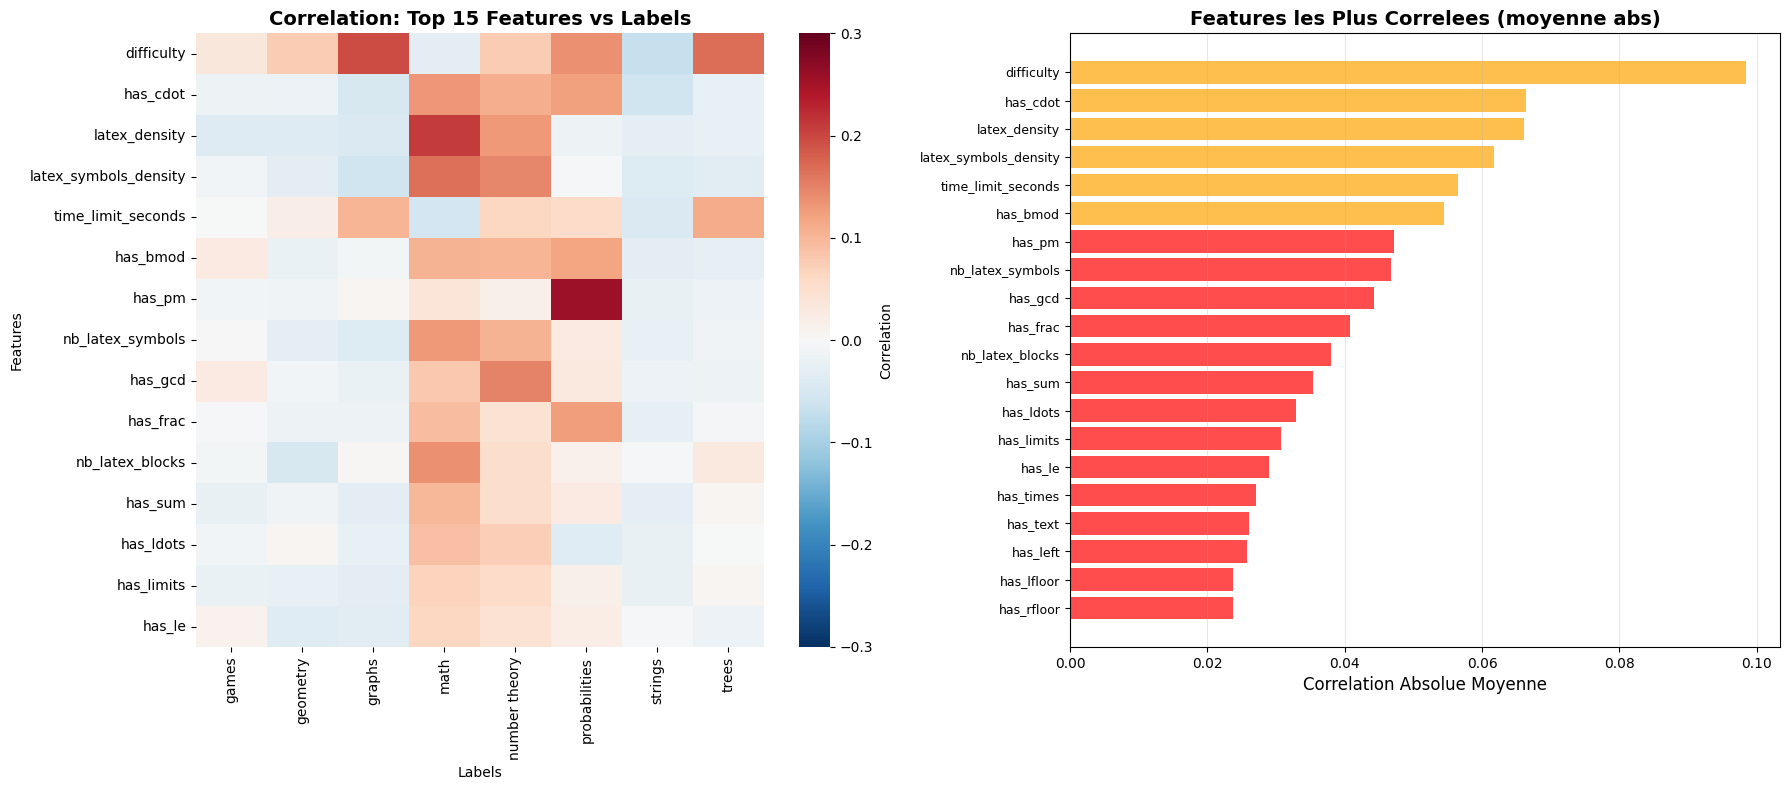

Visualisations de correlation generees


In [51]:
# Visualisation: Heatmap de correlation
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap 1: Top 15 features vs tous les labels
ax1 = axes[0]
top_15_features = mean_abs_corr.head(15).index.tolist()
corr_subset = corr_df.loc[top_15_features]

sns.heatmap(
    corr_subset,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={'label': 'Correlation'},
    ax=ax1
)
ax1.set_title('Correlation: Top 15 Features vs Labels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Labels')
ax1.set_ylabel('Features')

# Heatmap 2: Correlation absolue moyenne par feature
ax2 = axes[1]
mean_corr_sorted = mean_abs_corr.head(20).sort_values(ascending=True)
colors = ['green' if x > 0.1 else 'orange' if x > 0.05 else 'red' for x in mean_corr_sorted.values]
ax2.barh(range(len(mean_corr_sorted)), mean_corr_sorted.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(mean_corr_sorted)))
ax2.set_yticklabels([f[:30] for f in mean_corr_sorted.index], fontsize=9)
ax2.set_xlabel('Correlation Absolue Moyenne', fontsize=12)
ax2.set_title('Features les Plus Correlees (moyenne abs)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualisations de correlation generees")


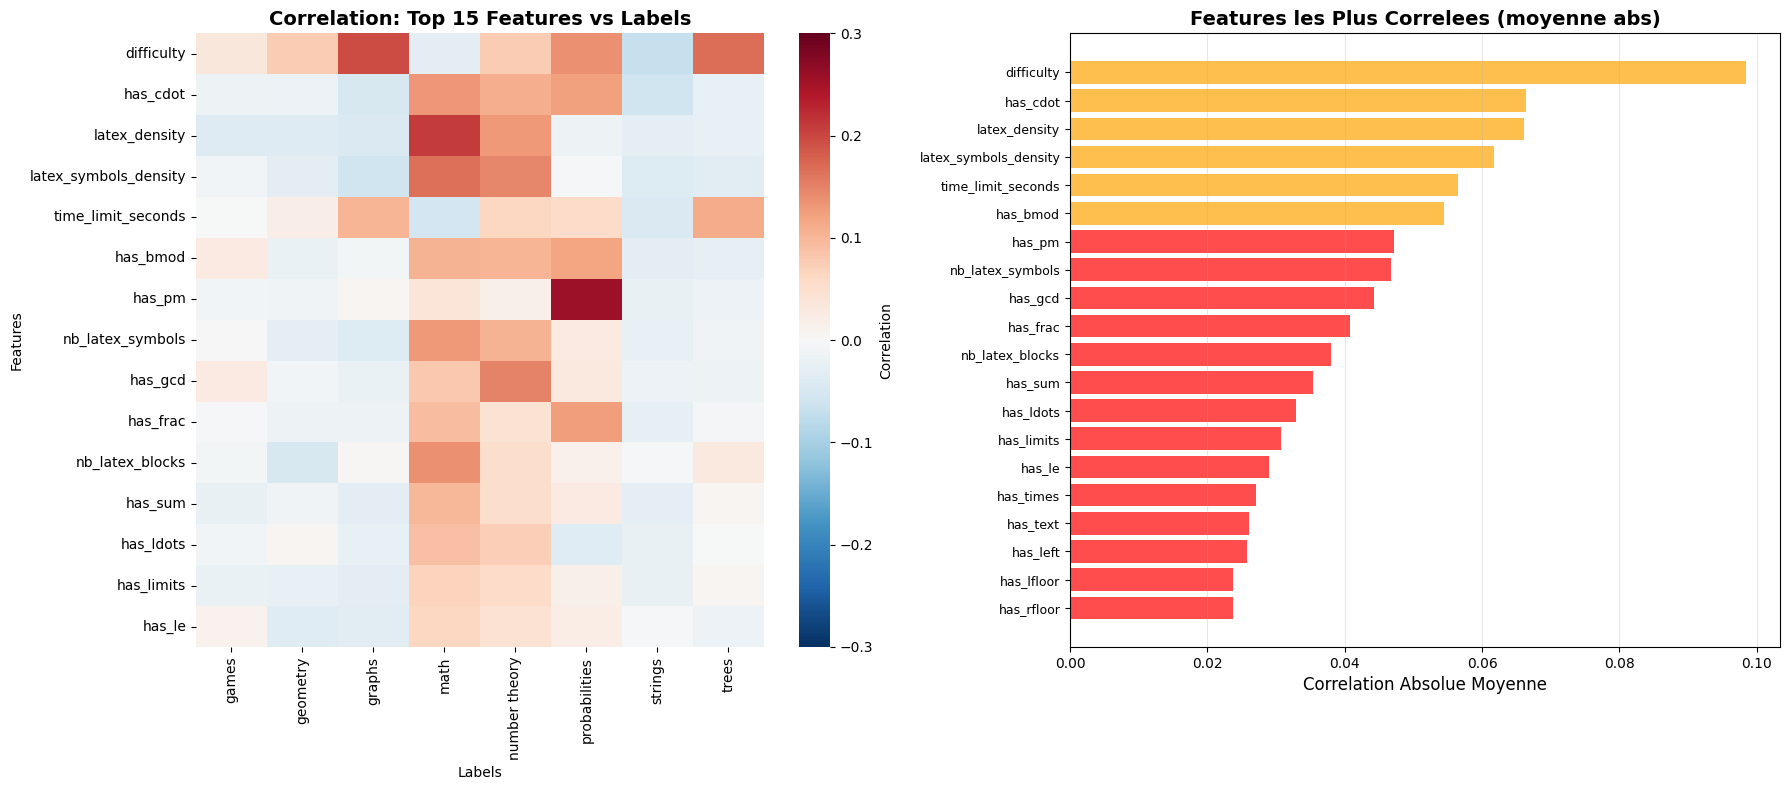

Visualisations generees


In [52]:
# Visualisation: Heatmap de correlation
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap 1: Top 15 features vs tous les labels
ax1 = axes[0]
top_15_features = mean_abs_corr.head(15).index.tolist()
corr_subset = corr_df.loc[top_15_features]

sns.heatmap(
    corr_subset,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={'label': 'Correlation'},
    ax=ax1
)
ax1.set_title('Correlation: Top 15 Features vs Labels', fontsize=14, fontweight='bold')
ax1.set_xlabel('Labels')
ax1.set_ylabel('Features')

# Heatmap 2: Correlation absolue moyenne par feature
ax2 = axes[1]
mean_corr_sorted = mean_abs_corr.head(20).sort_values(ascending=True)
colors = ['green' if x > 0.1 else 'orange' if x > 0.05 else 'red' for x in mean_corr_sorted.values]
ax2.barh(range(len(mean_corr_sorted)), mean_corr_sorted.values, color=colors, alpha=0.7)
ax2.set_yticks(range(len(mean_corr_sorted)))
ax2.set_yticklabels([f[:30] for f in mean_corr_sorted.index], fontsize=9)
ax2.set_xlabel('Correlation Absolue Moyenne', fontsize=12)
ax2.set_title('Features les Plus Correlees (moyenne abs)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualisations generees")


In [53]:
# Calculer les metriques globales
print("\n" + "="*80)
print("METRIQUES GLOBALES")
print("="*80)

# Micro-F1
micro_f1_train = f1_score(y_train, y_train_pred, average='micro')
micro_f1_val = f1_score(y_val, y_val_pred, average='micro')

# Macro-F1
macro_f1_train = f1_score(y_train, y_train_pred, average='macro')
macro_f1_val = f1_score(y_val, y_val_pred, average='macro')

# Hamming Loss
hamming_train = hamming_loss(y_train, y_train_pred)
hamming_val = hamming_loss(y_val, y_val_pred)

# Precision et Recall globaux
micro_prec_train = precision_score(y_train, y_train_pred, average='micro')
micro_prec_val = precision_score(y_val, y_val_pred, average='micro')
micro_rec_train = recall_score(y_train, y_train_pred, average='micro')
micro_rec_val = recall_score(y_val, y_val_pred, average='micro')

print("\n--- Micro-averaged (global) ---")
print(f"TRAIN:")
print(f"  Micro-F1:        {micro_f1_train:.4f}")
print(f"  Micro-Precision: {micro_prec_train:.4f}")
print(f"  Micro-Recall:    {micro_rec_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Micro-F1:        {micro_f1_val:.4f}")
print(f"  Micro-Precision: {micro_prec_val:.4f}")
print(f"  Micro-Recall:    {micro_rec_val:.4f}")

print("\n--- Macro-averaged (par label) ---")
print(f"TRAIN:")
print(f"  Macro-F1:        {macro_f1_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Macro-F1:        {macro_f1_val:.4f}")

print("\n--- Hamming Loss ---")
print(f"TRAIN:")
print(f"  Hamming Loss:    {hamming_train:.4f}")

print(f"\nVALIDATION:")
print(f"  Hamming Loss:    {hamming_val:.4f}")

print("\n" + "="*80)



METRIQUES GLOBALES

--- Micro-averaged (global) ---
TRAIN:
  Micro-F1:        0.7624
  Micro-Precision: 0.6472
  Micro-Recall:    0.9276

VALIDATION:
  Micro-F1:        0.5489
  Micro-Precision: 0.4833
  Micro-Recall:    0.6350

--- Macro-averaged (par label) ---
TRAIN:
  Macro-F1:        0.7759

VALIDATION:
  Macro-F1:        0.5344

--- Hamming Loss ---
TRAIN:
  Hamming Loss:    0.0499

VALIDATION:
  Hamming Loss:    0.0898



In [54]:
# Calculer les metriques par label
print("\n" + "="*80)
print("METRIQUES PAR LABEL (VALIDATION)")
print("="*80)

# Calculer F1, Precision, Recall pour chaque label
f1_per_label = f1_score(y_val, y_val_pred, average=None)
precision_per_label = precision_score(y_val, y_val_pred, average=None, zero_division=0)
recall_per_label = recall_score(y_val, y_val_pred, average=None, zero_division=0)

# Creer un DataFrame pour affichage propre
metrics_per_label = pd.DataFrame({
    'Label': [col.replace('target_', '') for col in target_columns_sorted],
    'F1': f1_per_label,
    'Precision': precision_per_label,
    'Recall': recall_per_label,
    'Support': y_val.sum(axis=0)
})

# Trier par F1 decroissant
metrics_per_label = metrics_per_label.sort_values('F1', ascending=False).reset_index(drop=True)

print("\n" + "-"*80)
print(f"{'Label':<25} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Support':>8}")
print("-"*80)

for idx, row in metrics_per_label.iterrows():
    print(f"{row['Label']:<25} {row['F1']:>8.4f} {row['Precision']:>10.4f} {row['Recall']:>8.4f} {row['Support']:>8.0f}")

print("-"*80)
print(f"{'MACRO-AVERAGE':<25} {metrics_per_label['F1'].mean():>8.4f} {metrics_per_label['Precision'].mean():>10.4f} {metrics_per_label['Recall'].mean():>8.4f} {metrics_per_label['Support'].sum():>8.0f}")
print("="*80)



METRIQUES PAR LABEL (VALIDATION)

--------------------------------------------------------------------------------
Label                           F1  Precision   Recall  Support
--------------------------------------------------------------------------------
games                       0.6829     0.5833   0.8235       17
strings                     0.6788     0.5773   0.8235       68
trees                       0.5812     0.5152   0.6667       51
graphs                      0.5687     0.4918   0.6742       89
math                        0.5514     0.5134   0.5956      225
geometry                    0.5000     0.4412   0.5769       26
number theory               0.3862     0.3182   0.4912       57
probabilities               0.3256     0.2500   0.4667       15
--------------------------------------------------------------------------------
MACRO-AVERAGE               0.5344     0.4613   0.6398      548


### 9.5 Visualisation des Performances


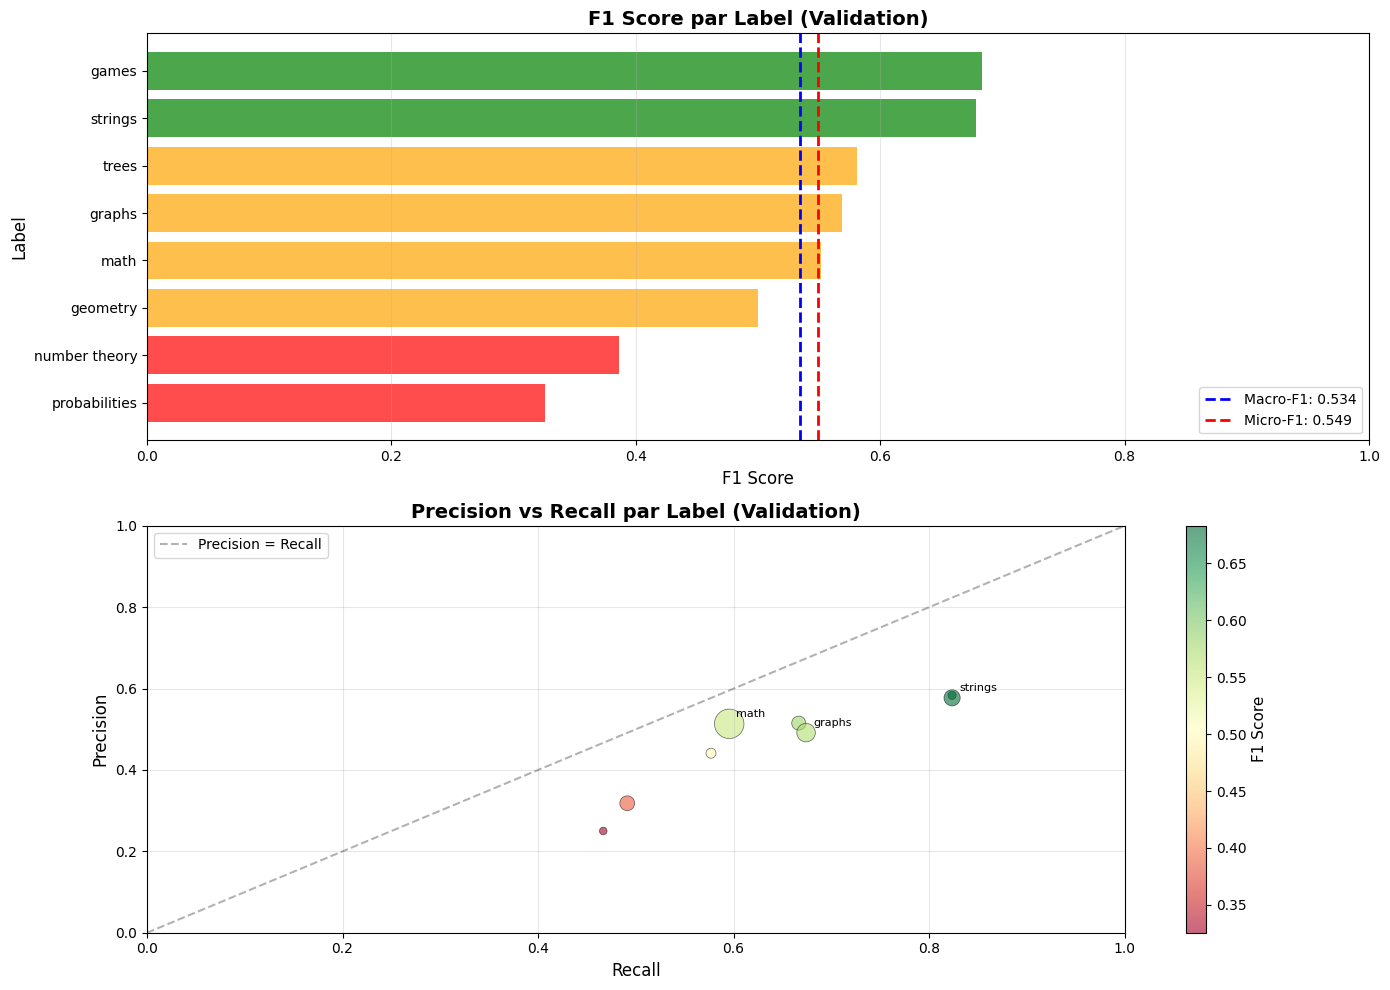

Visualisations generees


In [55]:
import matplotlib.pyplot as plt

# Visualisation F1 par label
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: F1 Score par label
ax1 = axes[0]
metrics_sorted = metrics_per_label.sort_values('F1', ascending=True)
colors = ['green' if f1 >= 0.6 else 'orange' if f1 >= 0.4 else 'red' for f1 in metrics_sorted['F1']]
ax1.barh(metrics_sorted['Label'], metrics_sorted['F1'], color=colors, alpha=0.7)
ax1.axvline(x=macro_f1_val, color='blue', linestyle='--', linewidth=2, label=f'Macro-F1: {macro_f1_val:.3f}')
ax1.axvline(x=micro_f1_val, color='red', linestyle='--', linewidth=2, label=f'Micro-F1: {micro_f1_val:.3f}')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_ylabel('Label', fontsize=12)
ax1.set_title('F1 Score par Label (Validation)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim([0, 1])

# Plot 2: Precision vs Recall par label
ax2 = axes[1]
scatter = ax2.scatter(
    metrics_per_label['Recall'], 
    metrics_per_label['Precision'],
    c=metrics_per_label['F1'],
    s=metrics_per_label['Support']*2,
    alpha=0.6,
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=0.5
)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Precision = Recall')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision vs Recall par Label (Validation)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

# Colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('F1 Score', fontsize=11)

# Annoter les labels les plus importants
for idx, row in metrics_per_label.nlargest(3, 'Support').iterrows():
    ax2.annotate(
        row['Label'], 
        (row['Recall'], row['Precision']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

print("Visualisations generees")


## 10. Resume Final


In [56]:
print("="*80)
print("RESUME FINAL - TF-IDF V1 + BASELINE")
print("="*80)

print("\n### PREPROCESSING & TF-IDF ###")
print(f"\nDATA:")
print(f"  Nombre de documents (TRAIN):        {n_docs:>8,}")
print(f"  Documents vides/courts (<50 chars): {(df['text_length'] < 50).sum():>8,}")
print(f"  Documents avec MATHBLOCK:           {docs_with_mathblock:>8,}")

print(f"\nPREPROCESSING:")
print(f"  Commandes LaTeX tokenisees:         {len(LATEX_COMMANDS_TO_TOKEN):>8}")
print(f"  Tokens numeriques:                  4 (NUM_INT, NUM_FLOAT, NUM_EXP, NUM_BIN)")
print(f"    NUM_INT occurrences:              {num_int_count:>12,}")
print(f"    NUM_FLOAT occurrences:            {num_float_count:>12,}")
print(f"    NUM_EXP occurrences:              {num_exp_count:>12,}")
print(f"    NUM_BIN occurrences:              {num_bin_count:>12,}")

print(f"\nVOCABULAIRE:")
print(f"  Tokens uniques (brut):              {len(token_counts):>12,}")
print(f"  Vocabulaire TF-IDF final:           {vocab_size:>12,} tokens")
print(f"  Reduction vocabulaire:              ~{(1 - vocab_size / 61678) * 100:.1f}% vs V1 sans tokenisation")

print(f"\nTF-IDF MATRICE:")
print(f"  Shape:                              {X_tfidf.shape}")
print(f"  Densite:                            {density:>12.6f} ({density * 100:.4f}%)")
print(f"  Memoire:                            {memory_mb:>12.2f} MB")

print("\n### MODELISATION BASELINE ###")
print(f"\nMODELE:")
print(f"  Type:                               OneVsRestClassifier(LogisticRegression)")
print(f"  Temps entrainement:                 {train_time:.2f}s ({train_time/60:.2f} min)")

print(f"\nPERFORMANCES (VALIDATION):")
print(f"  Micro-F1:                           {micro_f1_val:>8.4f}")
print(f"  Macro-F1:                           {macro_f1_val:>8.4f}")
print(f"  Hamming Loss:                       {hamming_val:>8.4f}")
print(f"  Micro-Precision:                    {micro_prec_val:>8.4f}")
print(f"  Micro-Recall:                       {micro_rec_val:>8.4f}")

print(f"\nLABELS:")
print(f"  Nombre de labels:                   {len(target_columns_sorted)}")
print(f"  Meilleur F1 (label):                {metrics_per_label.iloc[0]['Label']} ({metrics_per_label.iloc[0]['F1']:.4f})")
print(f"  Moins bon F1 (label):               {metrics_per_label.iloc[-1]['Label']} ({metrics_per_label.iloc[-1]['F1']:.4f})")

print("\n### ARTEFACTS SAUVEGARDES ###")
print(f"  - {vectorizer_file.name}")
print(f"  - {tfidf_matrix_file.name}")
print(f"  - {df_output_file.name}")

print("\n" + "="*80)
print("NOTEBOOK TERMINE")
print("Baseline etablie - Pret pour optimisations")
print("="*80)


RESUME FINAL - TF-IDF V1 + BASELINE

### PREPROCESSING & TF-IDF ###

DATA:
  Nombre de documents (TRAIN):           3,979
  Documents vides/courts (<50 chars):        0
  Documents avec MATHBLOCK:              2,235

PREPROCESSING:
  Commandes LaTeX tokenisees:               11
  Tokens numeriques:                  4 (NUM_INT, NUM_FLOAT, NUM_EXP, NUM_BIN)
    NUM_INT occurrences:                    94,971
    NUM_FLOAT occurrences:                     688
    NUM_EXP occurrences:                        13
    NUM_BIN occurrences:                       659

VOCABULAIRE:
  Tokens uniques (brut):                    17,346
  Vocabulaire TF-IDF final:                  5,871 tokens
  Reduction vocabulaire:              ~90.5% vs V1 sans tokenisation

TF-IDF MATRICE:
  Shape:                              (3979, 5871)
  Densite:                                0.015527 (1.5527%)
  Memoire:                                    2.77 MB

### MODELISATION BASELINE ###

MODELE:
  Type:                